In [1]:
import matplotlib.pyplot as plt 
from sklearn.datasets import make_blobs
import pandas as pd 
import numpy as np

In [3]:
x,y = make_blobs(n_samples=1000, n_features=2, centers=3, random_state=42)

In [5]:
x.shape

(1000, 2)

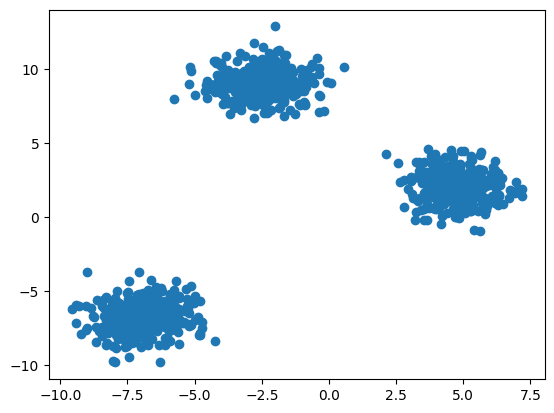

In [10]:
# plt.scatter(x[:,0],x[:,1],c=y)
plt.scatter(x[:,0],x[:,1])

In [11]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

In [12]:
from sklearn.cluster import KMeans

### How to find the value of K

In [ ]:
## Manual Process
## Elbow techinque
wcss = []
for k in range(1,11) : 
    kmeans = KMeans(n_clusters=k, init="k-means++")
    kmeans.fit(x_train)
    wcss.append(kmeans.inertia_)

In [14]:
wcss

[52946.116849197206,
 15369.674523316213,
 1599.7085950090784,
 1421.3424263551024,
 1248.8330832187396,
 1054.3114248077904,
 962.9685204438125,
 844.7952372974221,
 777.8338847491149,
 685.7383190321217]

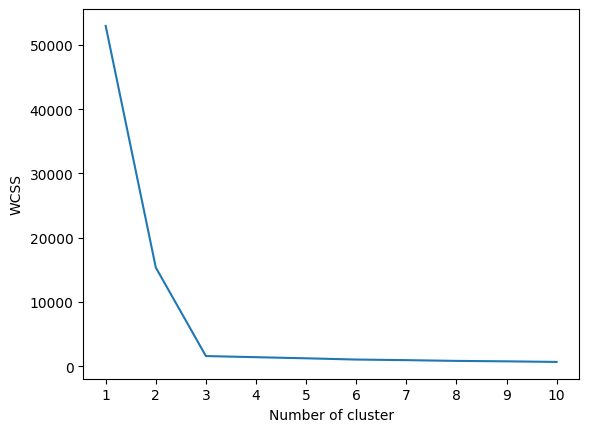

In [16]:
plt.plot(range(1,11), wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of cluster")
plt.ylabel("WCSS")
plt.show()

In [17]:
kmeans = KMeans(n_clusters=3, init="k-means++")

In [21]:
y_lables= kmeans.fit_predict(x_train)

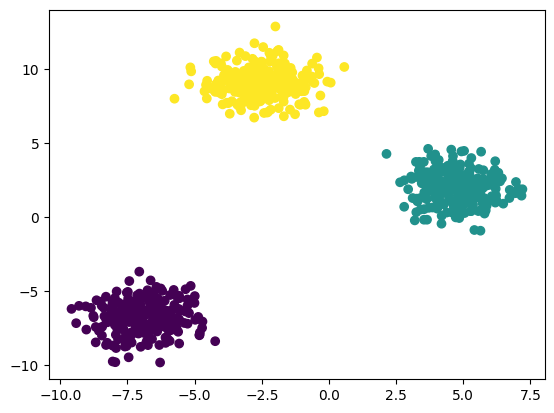

In [24]:
plt.scatter(x_train[:,0],x_train[:,1], c=y_lables)

In [25]:
y_test_lables= kmeans.predict(x_test)

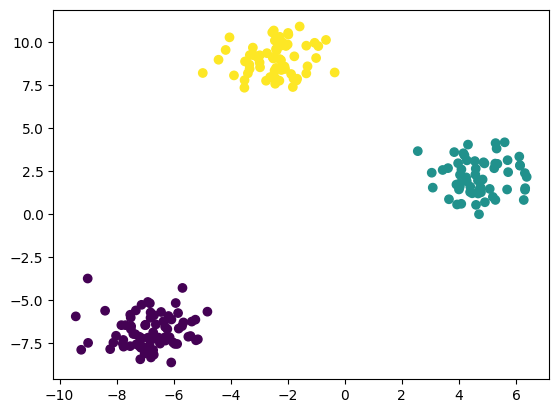

In [26]:
plt.scatter(x_test[:,0],x_test[:,1],c=y_test_lables)

In [28]:
## Automatic method --> Knee location
!pip install kneed


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [30]:
from kneed import KneeLocator

In [34]:
kl = KneeLocator(range(1,11), wcss, curve="convex", direction="decreasing")

In [35]:
kl.elbow

np.int64(3)

In [36]:
## Performance meteric
from sklearn.metrics import silhouette_score
silhouette_coefficients=[]
for k in range(2,11):
    kmeans = KMeans(n_clusters=k, init="k-means++")
    kmeans.fit(x_train)
    score = silhouette_score(x_train, kmeans.labels_)
    silhouette_coefficients.append(score)

In [37]:
silhouette_coefficients

[0.5090539335647752,
 0.8413954746484233,
 0.6541766584298075,
 0.49705536967730596,
 0.3092838933884651,
 0.31697655521138374,
 0.3242454756544215,
 0.3363185951351252,
 0.3363433566436433]